
# Generador de señales discretas

Este notebook implementa funciones para generar señales discretas en el tiempo:
- Senoidal
- Cuadrada
- Triangular
- Diente de sierra
- Pulso


## Parámetros utilizados

- fs: frecuencia de muestreo [Hz]
- nn: cantidad de muestras
- ff: frecuencia de la señal [Hz]
- vmax: amplitud pico [V]
- dc: offset [V]
- ph: fase [rad]
- duty: duty cycle


In [5]:
import numpy as np
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * np.sin( 2*np.pi * ff * tt + ph )
    return tt, xx


def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, ph=0, duty=0.5, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + np.where(((tt * ff + ph/(2*np.pi)) % 1) < duty, vmax, -vmax)
    return tt, xx


def mi_funcion_triangular(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * (2 * np.abs(2 * ((tt * ff + ph/(2*np.pi)) % 1) - 1) - 1)
    return tt, xx


def mi_funcion_diente_sierra(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * (2 * ((tt * ff + ph/(2*np.pi)) % 1) - 1)
    return tt, xx


def mi_funcion_pulso(vmax=1, dc=0, t0=0, ancho=1, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * np.where((tt >= t0) & (tt <= t0 + ancho), 1, 0)
    return tt, xx

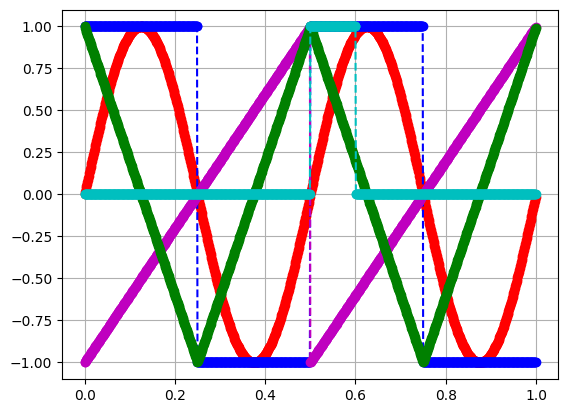

In [6]:
import matplotlib.pyplot as plt

# == Ejemplo de uso ===
# Parámetros de la simulación
fs = 1000 # Hz
N = fs  # Resolución espectral fs/N = 1Hz, tiempo de simulación 1seg

# Parámetros de las señales
fx = 2  # Hz
ax = 1  # V
dx = 0  # V
px = 0  # rad
duty = 0.5
t0x = 0.5  # seg
tfx = 0.1 # seg

# Generar señales
tt1, xx1 = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
tt2, xx2 = mi_funcion_cuadrada(vmax=ax, dc=dx, ff=fx, ph=px, duty=duty, nn=N, fs=fs)
tt3, xx3 = mi_funcion_diente_sierra(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
tt4, xx4 = mi_funcion_triangular(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
tt5, xx5 = mi_funcion_pulso(vmax=ax, dc=dx, t0=t0x, ancho=tfx, nn=N, fs=fs)

# Ploteo
plt.plot(tt1, xx1, 'o--', color = 'r')
plt.plot(tt2, xx2, 'o--', color = 'b')
plt.plot(tt3, xx3, 'o--', color = 'm')
plt.plot(tt4, xx4, 'o--', color = 'g')
plt.plot(tt5, xx5, 'o--', color = 'c')
plt.grid()
plt.show()